# Storm Hidden-Markov Model

## Model

### Transition/transfer matrix
Latent environment state $L \in \{\mathrm{calm}, \mathrm{storm}\}$ with transition (transfer) matrix
$$
    T = 
    \begin{pmatrix}
    \Gamma_{\text{calm} \to \text{calm}} & \Gamma_{\text{calm} \to \text{storm}} \\
    \Gamma_{\text{storm} \to \text{calm}} & \Gamma_{\text{storm} \to \text{storm}}
    \end{pmatrix}.
$$
Let $a = \Gamma_{\text{calm} \to \text{storm}}$ and $b = \Gamma_{\text{storm} \to \text{calm}}$, then
$$
    T = 
    \begin{pmatrix}
    1-a & a\\
    b & 1-b
    \end{pmatrix},
$$
with $a \ll b \ll 1$. Eigenvalues of $T$ are
$$
\lambda_1 = 1, \quad \lambda_2 = 1 - a - b,
$$
with spectral gap $\Delta = \lambda_1 - \lambda_2$ and correlation length $\xi = \frac{1}{-\ln \lambda_2}$
$$
\Delta = a + b \\
\xi = \frac{1}{-\ln (1 - a - b)}.
$$
Stationary left (right) eigenstate $\bra{l}$ ($\ket{r}$) corresponding to $\lambda_1 = 1$ are
$$
    \bra{l} = 
    \frac{1}{a+b}\begin{pmatrix}
    b & a
    \end{pmatrix},
    \quad
    \ket{r} = 
    \begin{pmatrix}
    1 \\ 1
    \end{pmatrix},
$$
satisfying $\bra{l}T = \bra{l}, \ T\ket{r} = \ket{r}, \ \braket{l|r} = 1$.
$$

### Emission operator
Denote $p_\mathrm{calm}^{(x)}$ ($p_\mathrm{storm}^{(x)}$) as the probability of emitting Pauli operator $x$ when the environment transitions to the calm (storm) state. The emission operators are
$$
A^{(x)} = T\mathrm{diag}(p_\mathrm{calm}^{(x)}, p_\mathrm{storm}^{(x)}),
$$
where we have used the standard HMM to MPS tensor mapping. For stationary storm fraction $\pi_\mathrm{storm} = \frac{a}{a+b}$, the average marginal rate for Pauli $x$ is
$$
\bar{p}^{(x)} = (1 - \pi_\mathrm{storm})p_\mathrm{calm}^{(x)} + \pi_\mathrm{storm}p_\mathrm{storm}^{(x)}.
$$

### SE Kraus representation
Working backwards, the system-environment Kraus operators for our model can be written as
$$
K_{i\to j}^{(x)} = \sqrt{T_{ij}}\sqrt{p^{(x)}_j}\ket{j}\!\!\bra{i}_E \otimes \sigma_S^{(x)},
$$
which can be further dilated to a Stinespring isometry.

# QEC

### Noise model

$$
p_\mathrm{calm}^{(x)} = 0, \quad x \neq I \\
p_\mathrm{storm}^{(x)} = \frac{1}{4}, \quad \forall x \\
$$

$$
\bar{p}^{(x\neq I)} =\frac{3}{4} \frac{a}{a+b}
$$

### Simulations

In [1]:
import csv
import re
import sinter
import stim
from corrqec2.sampling import SinterSampler
from corrqec2.noisemodels import StormModel
from corrqec2.experiments import SurfaceCodeMemory
import matplotlib.pyplot as plt

def calc_a_b(p_bar, Delta):
    """Calculate storm model parameters a, b for given spectral gap Delta (=a+b) and fixed marginal error rate p_bar."""
    a = 4 * p_bar * Delta / 3
    b = Delta * (1 - 4 * p_bar / 3)
    return a, b

def sample_logical_error_rate(Delta, p_bar, n_shots, experiment_args, noise_model_args, min_batch_size, num_workers=1, print_progress=True):

    a, b = calc_a_b(p_bar, Delta)

    noise_model_args['model_params'] = {
        'a': a,
        'b': b,
        'emissions': [[1., 0., 0., 0.], [0.25, 0.25, 0.25, 0.25]],
    }

    meta = {
        'experiment': 'SurfaceCodeMemory',
        'experiment_args': experiment_args,
        'noise_model': 'StormModel',
        'noise_model_args': noise_model_args,
        'decoder': 'Pymatching',
        'min_batch_size': min_batch_size,
        'marginalized_detector_error_model': True,
    }
    task = sinter.Task(circuit=stim.Circuit(), json_metadata=meta)
    sampler = SinterSampler()
    stats = sinter.collect(tasks=[task], num_workers=num_workers, decoders='custom_sampler', custom_decoders={'custom_sampler': sampler}, max_shots=n_shots, print_progress=print_progress)

    n_shots = stats[0].shots
    n_errors = stats[0].errors

    return n_errors / n_shots

In [2]:
experiment_args = {'distance': 11, 'rounds': '3d', 'memory_type': 'Z'}
p_gate = 0.005
gate_noise = {
    #'after_identity_depolarization': p_gate,
    'after_clifford_depolarization': p_gate,
    'before_measure_flip_probability': p_gate,
    #'after_reset_flip_probability': p_gate,
}
noisy_qubit_types = 'syndrome'
noise_model_args = {
    'gate_noise': gate_noise,
    'noisy_qubit_types': noisy_qubit_types,
}
n_shots = 10_000
min_batch_size = 1_000
p_bar = 0.005
num_workers = 5

p_logicals = []
Deltas = [0.5, 0.25, 0.1, 0.05, 0.025, 0.01, 0.001, 0.0001]
for Delta in Deltas:
    p_logical = sample_logical_error_rate(Delta, p_bar, n_shots, experiment_args, noise_model_args, min_batch_size, num_workers=num_workers, print_progress=False)
    p_logicals.append(p_logical)

Starting 5 workers...
1 tasks left:
  workers        decoder eta shots_left errors_seen json_metadata                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
        5 custom_sampler   ?       9000          10 experiment=SurfaceCodeMemory,experiment_args={'distance': 11, 'rounds': '3d', 'memory_type': 'Z'},noise_model=StormModel,noise_model_args={'gate_noise': {'after_clifford_depolarization': 0.005, 'before_measure_flip_probability': 0.005}, 'noisy_qubit_types': 'syndrome', 'model_params': {'a': 0.0033333333333333335, 'b': 0.49666666666666665, 'emissions': [[1.0, 0.0, 0.0, 0.0], 

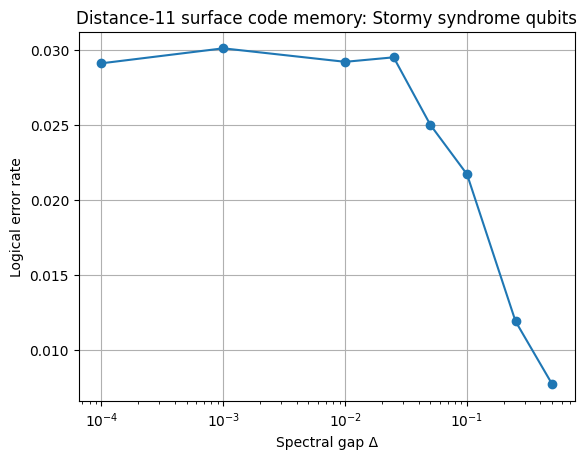

In [3]:
plt.semilogx(Deltas, p_logicals, marker='o')
plt.xlabel('Spectral gap Δ')
plt.ylabel('Logical error rate')
plt.title('Distance-11 surface code memory: Stormy syndrome qubits')
plt.grid(True)

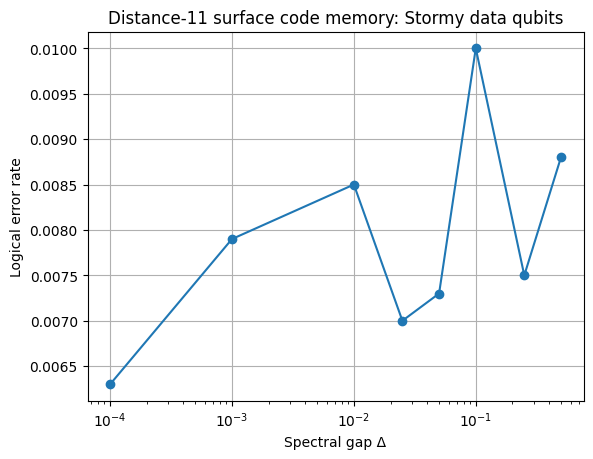

In [17]:
noisy_qubit_types = 'data'
noise_model_args = {
    'gate_noise': gate_noise,
    'noisy_qubit_types': noisy_qubit_types,
}
p_logicals = []
for Delta in Deltas:
    p_logical = sample_logical_error_rate(Delta, p_bar, n_shots, experiment_args, noise_model_args, min_batch_size, num_workers=num_workers, print_progress=False)
    p_logicals.append(p_logical)

plt.semilogx(Deltas, p_logicals, marker='o')
plt.xlabel('Spectral gap Δ')
plt.ylabel('Logical error rate')
plt.title('Distance-11 surface code memory: Stormy data qubits')
plt.grid(True)

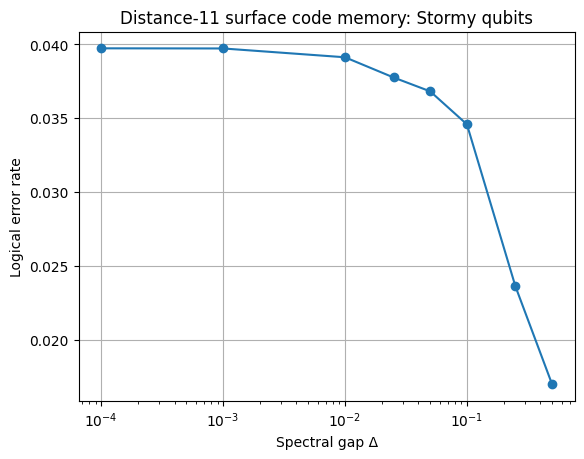

In [5]:
noisy_qubit_types = 'all'
noise_model_args = {
    'gate_noise': gate_noise,
    'noisy_qubit_types': noisy_qubit_types,
}
p_logicals = []
for Delta in Deltas:
    p_logical = sample_logical_error_rate(Delta, p_bar, n_shots, experiment_args, noise_model_args, min_batch_size, num_workers=num_workers, print_progress=False)
    p_logicals.append(p_logical)

plt.semilogx(Deltas, p_logicals, marker='o')
plt.xlabel('Spectral gap Δ')
plt.ylabel('Logical error rate')
plt.title('Distance-11 surface code memory: Stormy qubits')
plt.grid(True)

## Test HMM libraries

In [ ]:
a = 0.01
b = 0.1

pi_a = a / (a + b)
pi_b = b / (a + b)

p_X_calm = 0
p_Y_calm = 0
p_Z_calm = 0
p_I_calm = 1

p_X_storm = 0.25
p_Y_storm = 0.25
p_Z_storm = 0.25
p_I_storm = 0.25

In [ ]:
sample_length = 20
num_samples = 100

#### Promeganate
(No GPU accelerated sampling)

In [ ]:
import torch
from pomegranate.distributions import Categorical
from pomegranate.hmm import DenseHMM

ModuleNotFoundError: No module named 'torch'

In [ ]:
calm = Categorical([[p_I_calm, p_X_calm, p_Y_calm, p_Z_calm]])
storm = Categorical([[p_I_storm, p_X_storm, p_Y_storm, p_Z_storm]])

model = DenseHMM(
    distributions = [calm, storm],
    edges = [[1.0 - a, a], [b, 1.0 - b]],
    starts = [pi_b, pi_a],
    sample_length = sample_length,
)

In [ ]:
%timeit model.sample(n=num_samples)[0].flatten()

146 ms ± 28.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


#### Dynamax (Jax)

In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax import vmap

from dynamax.hidden_markov_model import CategoricalHMM

In [ ]:
# num_states: Number of hidden states
# emission_dim: Dimension of the emission space
# num_classes: Size of the discrete emission alphabet

hmm = CategoricalHMM(num_states=2, emission_dim=1, num_classes=4)
params, _ = hmm.initialize(
    initial_probs=jnp.array([pi_b, pi_a]),
    transition_matrix=jnp.array([[1.0 - a, a], [b, 1.0 - b]]),
    emission_probs=jnp.array([[p_I_calm, p_X_calm, p_Y_calm, p_Z_calm], [p_I_storm, p_X_storm, p_Y_storm, p_Z_storm]]).reshape(2, 1, 4)
    )

In [ ]:
key = jr.PRNGKey(np.random.randint(0, 2**32))

Single sample

In [ ]:
# Sample one sequence
hmm.sample(params, key=key, num_timesteps=sample_length)[1].flatten()

Array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

Batched sampling

In [ ]:
keys = jr.split(jr.PRNGKey(1), num_samples)
%timeit vmap(lambda k: hmm.sample(params, k, sample_length))(keys)

483 ms ± 13.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
keys = jr.split(key, num_samples)
output = vmap(lambda k: hmm.sample(params, k, sample_length))(keys)

In [ ]:
output[1].shape

(100, 20, 1)

Nice gains from GPU acceleration of HMM sampling for batched sampling